### What we often do in this use-case
    High level over-view..
    
   
    Note :->>
    
    We will solve most of those challenges that we often face in real world..
    we will focus primarily on each & every part of data science life-cycle..
    
    
     Life- Cycle of Data Science Project :
        a) Data collection
        b) Perform Data Cleaning / Data Preparation / Data Pre-processing
        c) Data visuaslisation(EDA)
        d) Perform feature engineering
            I)  Feature encoding
            II) checking outliers & impute it..
            III)Feature selection or feature importance
            
        e) build machine leaning model & dump it..
        f) Automate ML Pipeline
        g) hypertune ml model..along with cross validation

    

## 1.. Lets read data !

In [589]:
## import necessary packages !

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing dataset
    Since data is in form of excel file we have to use pandas read_excel to load the data


In [590]:
train_data = pd.read_excel(r"Data_Train.xlsx")

In [591]:
train_data.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218


In [592]:
train_data.tail(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


## 2.. Lets deal with missing values ..

In [593]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [594]:
'''

10 features belong to object data-type , ie.. in context to Python , they belong to string data-type


1 feature belong to int64 nature  , ie
Variations of int are : ('int64','int32','int16') in numpy library..



Int16 is a 16 bit signed integer , it means it can store both positive & negative values
int16 has has a range of  (2^15 − 1) to -2^15
int16 has a length of 16 bits (2 bytes).. ie Int16 uses 16 bits to store data


Int32 is a 32 bit signed integer , it means it storesboth positive & negative values
int32 has has a range of (2³¹ − 1) to  -2^31
int32 has a length of 32 bits (4 bytes),, ie Int32 uses 32 bits to store data


Int64 is a 64 bit signed integer , it means it can store both positive & negative values
int64 has has a range of  (2^63 − 1) to -2^63
int64 has a length of 64 bits (8 bytes) , ie Int64 uses 64 bits to store data

The only difference is that int64 has max range of storing numbers , then comes int32 , then 16 , then int8

That means that Int64’s take up twice as much memory-and doing
operations on them may be a lot slower in some machine architectures.

However, Int64’s can represent numbers much more accurately than
32 bit floats.They also allow much larger numbers to be stored..







The memory usage of a DataFrame (including the index) is shown when calling the info().
A configuration option, display.memory_usage (see the list of options), specifies if the DataFrame’s memory usage
 will be displayed when invoking the df.info() method..

memory usage: 918.2+ KB
The + symbol indicates that the true memory usage could be higher,
because pandas does not count the memory used by values in columns with dtype=object


Passing memory_usage='deep' will enable a more accurate memory usage report .

'''

"\n\n10 features belong to object data-type , ie.. in context to Python , they belong to string data-type\n\n\n1 feature belong to int64 nature  , ie\nVariations of int are : ('int64','int32','int16') in numpy library..\n\n\n\nInt16 is a 16 bit signed integer , it means it can store both positive & negative values\nint16 has has a range of  (2^15 − 1) to -2^15\nint16 has a length of 16 bits (2 bytes).. ie Int16 uses 16 bits to store data\n\n\nInt32 is a 32 bit signed integer , it means it storesboth positive & negative values\nint32 has has a range of (2³¹ − 1) to  -2^31\nint32 has a length of 32 bits (4 bytes),, ie Int32 uses 32 bits to store data\n\n\nInt64 is a 64 bit signed integer , it means it can store both positive & negative values\nint64 has has a range of  (2^63 − 1) to -2^63\nint64 has a length of 64 bits (8 bytes) , ie Int64 uses 64 bits to store data\n\nThe only difference is that int64 has max range of storing numbers , then comes int32 , then 16 , then int8\n\nThat mean

In [595]:
## After loading it is important to check null/missing values in a column or a row
## Missing value :  values which occur when no data is recorded for an observation..

train_data.isnull().sum()

## train_data.isnull().sum(axis=0)
## by-default axis is 0 , ie it computes total missing values column-wise !

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [596]:
train_data['Total_Stops'].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
10678    False
10679    False
10680    False
10681    False
10682    False
Name: Total_Stops, Length: 10683, dtype: bool

In [597]:
### getting all the rows where we have missing value

train_data[train_data['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


#### as we have 1 missing value , I can directly drop these

In [598]:
train_data.dropna(inplace=True)

In [599]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [600]:
train_data.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

In [601]:
### In order to more accurate memory usage , u can leverage memory_usage="deep" in info()
train_data.info(memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10682 non-null  str  
 1   Date_of_Journey  10682 non-null  str  
 2   Source           10682 non-null  str  
 3   Destination      10682 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10682 non-null  str  
 6   Arrival_Time     10682 non-null  str  
 7   Duration         10682 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10682 non-null  str  
 10  Price            10682 non-null  int64
dtypes: int64(1), str(10)
memory usage: 6.3 MB


## 3.. Lets Perform Data Pre-process & extract Derived attributes from "Date_of_Journey"
        lets extract derived attributes from "Date_of_Journey" & fetch day , month , year !

In [602]:
data = train_data.copy()

In [603]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [604]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [605]:
data.dtypes

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

#### From description we can see that Date_of_Journey is a object data type,
     Therefore, we have to convert this datatype into timestamp so as to use this column properly for prediction,bcz our
     model will not be able to understand these string values,it just understand Time-stamp
    For this we require pandas to_datetime to convert object data type to datetime dtype.

In [606]:
'''
In date-time , we have 4 data-types in Pandas :
datetime64[ns] or datetime64[ns, tz]  or datetime64[ns, UTC] or dtype('<M8[ns]')
     means ‘big-endian’  , < is little-endian
     imagine , data represented a single unsigned 4-byte little-endian integer, the dtype string would be <u4..
     (u is type-character code for unsigned integer)

where ,   UTC = Coordinated Universal Time
          ns  = nano second
          tz  = time zone
          M =  M is a character of Data-time , just like int we have i for "Integer" ,


datetime64[ns] is a general dtype, while <M8[ns] is a specific dtype , ns is basicaly nano second..
Both are similar , it entirely how your numpy was compiled..

np.dtype('datetime64[ns]') == np.dtype('<M8[ns]')
## True

'''

'\nIn date-time , we have 4 data-types in Pandas :\ndatetime64[ns] or datetime64[ns, tz]  or datetime64[ns, UTC] or dtype(\'<M8[ns]\')\n     means ‘big-endian’  , < is little-endian\n     imagine , data represented a single unsigned 4-byte little-endian integer, the dtype string would be <u4..\n     (u is type-character code for unsigned integer)\n\nwhere ,   UTC = Coordinated Universal Time\n          ns  = nano second\n          tz  = time zone\n          M =  M is a character of Data-time , just like int we have i for "Integer" ,\n\n\ndatetime64[ns] is a general dtype, while <M8[ns] is a specific dtype , ns is basicaly nano second..\nBoth are similar , it entirely how your numpy was compiled..\n\nnp.dtype(\'datetime64[ns]\') == np.dtype(\'<M8[ns]\')\n## True\n\n'

In [607]:
def change_into_Datetime(col):
    data[col] = pd.to_datetime(data[col])

In [608]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [609]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')

In [610]:
for feature in ['Dep_Time', 'Arrival_Time' , 'Date_of_Journey']:
    change_into_Datetime(feature)

In [611]:
data.dtypes

Airline                       str
Date_of_Journey    datetime64[us]
Source                        str
Destination                   str
Route                         str
Dep_Time           datetime64[us]
Arrival_Time       datetime64[us]
Duration                      str
Total_Stops                   str
Additional_Info               str
Price                       int64
dtype: object

In [612]:
data["Journey_day"] = data['Date_of_Journey'].dt.day

In [613]:
data["Journey_month"] = data['Date_of_Journey'].dt.month

In [614]:
data["Journey_year"] = data['Date_of_Journey'].dt.year

In [615]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-04-04 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-04-04 05:50:00,2026-04-04 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-04-04 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019


## 4.. Lets try to clean Dep_Time & Arrival_Time & then extract Derived attributes ..

In [616]:
def extract_hour_min(df , col):
    df[col+"_hour"] = df[col].dt.hour
    df[col+"_minute"] = df[col].dt.minute
    return df.head(3)

In [617]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_day', 'Journey_month',
       'Journey_year'],
      dtype='str')

In [618]:
# Departure time is when a plane leaves the gate.

extract_hour_min(data , "Dep_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-04-04 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-04-04 05:50:00,2026-04-04 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-04-04 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25


In [619]:
extract_hour_min(data , "Arrival_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-04-04 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-04-04 05:50:00,2026-04-04 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-04-04 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [620]:
## we have extracted derived attributes from ['Arrival_Time' , "Dep_Time"] , so lets drop both these features ..
cols_to_drop = ['Arrival_Time' , "Dep_Time"]

data.drop(cols_to_drop , axis=1 , inplace=True )

In [621]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [622]:
data.shape

(10682, 16)

## 5.. lets analyse when will most of the flights take-off..

In [623]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute'],
      dtype='str')

In [624]:
#### Converting the flight Dep_Time into proper time i.e. mid_night, morning, afternoon and evening.

def flight_dep_time(x):
    '''
    This function takes the flight Departure time
    and convert into appropriate format.

    '''

    if (x>4) and (x<=8):
        return "Early Morning"

    elif (x>8) and (x<=12):
        return "Morning"

    elif (x>12) and (x<=16):
        return "Noon"

    elif (x>16) and (x<=20):
        return "Evening"

    elif (x>20) and (x<=24):
        return "Night"

    else:
        return "late night"

<Axes: xlabel='Dep_Time_hour'>

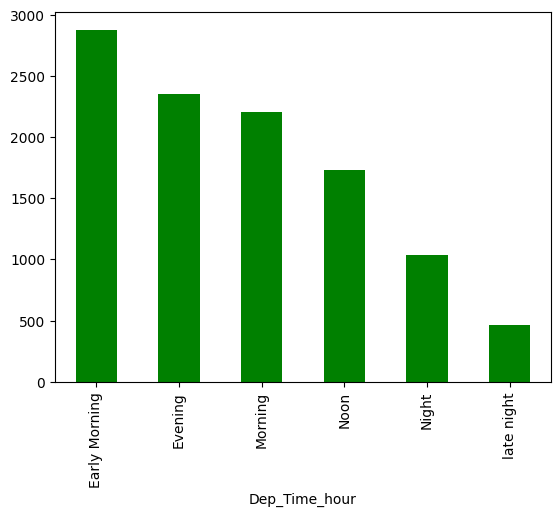

In [625]:
data['Dep_Time_hour'].apply(flight_dep_time).value_counts().plot(kind="bar" , color="g")

In [626]:
#### how to make above graph interactive , lets use Cufflinks & plotly to make it interactive !

In [627]:
###"""!pip install plotly
###!pip install chart_studio"""

In [628]:
#!pip install cufflinks

In [629]:
"""## how to use Plotly interactive plots directly with Pandas dataframes, First u need below set-up !

import plotly
import cufflinks as cf
from cufflinks.offline import go_offline
from plotly.offline import plot , iplot , init_notebook_mode , download_plotlyjs
init_notebook_mode(connected=True)
cf.go_offline()

## plot is a command of Matplotlib which is more old-school. It creates static charts
## iplot is an interactive plot. Plotly takes Python code and makes beautiful looking JavaScript plots."""


'## how to use Plotly interactive plots directly with Pandas dataframes, First u need below set-up !\n\nimport plotly\nimport cufflinks as cf\nfrom cufflinks.offline import go_offline\nfrom plotly.offline import plot , iplot , init_notebook_mode , download_plotlyjs\ninit_notebook_mode(connected=True)\ncf.go_offline()\n\n## plot is a command of Matplotlib which is more old-school. It creates static charts\n## iplot is an interactive plot. Plotly takes Python code and makes beautiful looking JavaScript plots.'

In [630]:
#data['Dep_Time_hour'].apply(flight_dep_time).value_counts().iplot(kind="bar", line_width=0)

In [631]:
"""import plotly.express as px

dep_counts = (
    data['Dep_Time_hour']
    .apply(flight_dep_time)
    .value_counts()
    .reset_index()
)

dep_counts.columns = ['Departure_Time', 'Count']

fig = px.bar(
    dep_counts,
    x='Departure_Time',
    y='Count',
    title='Flights by Departure Time Category'
)

fig.show()"""

"import plotly.express as px\n\ndep_counts = (\n    data['Dep_Time_hour']\n    .apply(flight_dep_time)\n    .value_counts()\n    .reset_index()\n)\n\ndep_counts.columns = ['Departure_Time', 'Count']\n\nfig = px.bar(\n    dep_counts,\n    x='Departure_Time',\n    y='Count',\n    title='Flights by Departure Time Category'\n)\n\nfig.show()"

## 6.. Pre-process Duration Feature & extract meaningful features from it..

### Lets Apply pre-processing on duration column,
    -->> Once we pre-processed our Duration feature , lets extract Duration hours and minute from duration..
    
    -->> As my ML model is not able to understand this duration as it contains string values ,
    thats why we have to tell our ML Model that this is hour & this is minute for each of the row ..

In [632]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25


In [633]:
def preprocess_duration(x):
    if 'h' not in x:
        x = '0h' + ' ' + x
    elif 'm' not in x:
        x = x + ' ' +'0m'

    return x

In [634]:
data['Duration'] = data['Duration'].apply(preprocess_duration)

In [635]:
data['Duration']

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: str

In [636]:
'''
    Now after pre-processing duration feature , still my ml_model is not able to understand duration
    bcz it is string data so any how we have to convert it into numerical(integer of float) values

'''

'\n    Now after pre-processing duration feature , still my ml_model is not able to understand duration\n    bcz it is string data so any how we have to convert it into numerical(integer of float) values\n\n'

In [637]:
data['Duration'][0]

'2h 50m'

In [638]:
'2h 50m'.split(' ')

['2h', '50m']

In [639]:
'2h 50m'.split(' ')[0]

'2h'

In [640]:
'2h 50m'.split(' ')[0][0:-1]

'2'

In [641]:
type('2h 50m'.split(' ')[0][0:-1])

str

In [642]:
int('2h 50m'.split(' ')[0][0:-1])

2

In [643]:
int('2h 50m'.split(' ')[1][0:-1])

50

In [644]:
data['Duration_hours'] = data['Duration'].apply(lambda x : int(x.split(' ')[0][0:-1]))

In [645]:
data['Duration_mins'] = data['Duration'].apply(lambda x : int(x.split(' ')[1][0:-1]))

In [646]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25


In [647]:
pd.to_timedelta(data["Duration"]).dt.components.hours

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: hours, Length: 10682, dtype: int64

In [648]:
data["Duration_hour"] = pd.to_timedelta(data["Duration"]).dt.components.hours

In [649]:
data["Duration_minute"] = pd.to_timedelta(data["Duration"]).dt.components.minutes

## 7.. Lets Analyse whether Duration impacts Price or not ?

In [650]:
data['Duration'] ## convert duration into total minutes duration ..

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: str

In [651]:
2*60

120

In [652]:
'2*60'

'2*60'

In [653]:
eval('2*60')

120

In [654]:
data['Duration_total_mins'] = data['Duration'].str.replace('h' ,"*60").str.replace(' ' , '+').str.replace('m' , "*1").apply(eval)

In [655]:
#data["Duration_in_minute"] = data["Duration_hour"]*60 + data["Duration_minute"]

In [656]:
data['Duration_total_mins']

0         170
1         445
2        1140
3         325
4         285
         ... 
10678     150
10679     155
10680     180
10681     160
10682     500
Name: Duration_total_mins, Length: 10682, dtype: int64

In [657]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_hour', 'Duration_minute',
       'Duration_total_mins'],
      dtype='str')

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

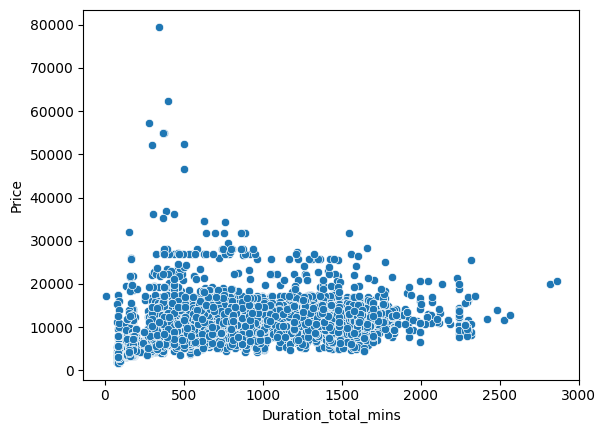

In [658]:
sns.scatterplot(x="Duration_total_mins" , y="Price" , data=data)

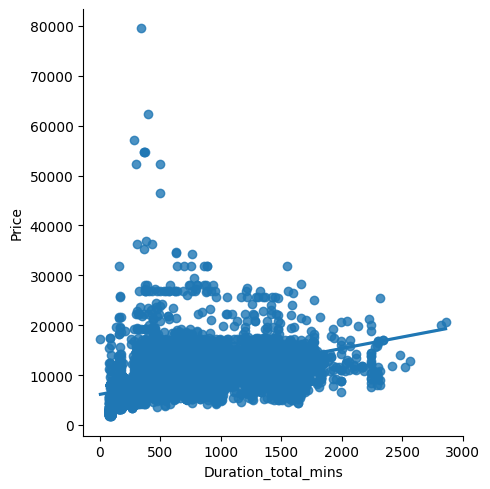

In [659]:
sns.lmplot(x="Duration_total_mins" , y="Price" , data=data)

### pretty clear that As the duration of minutes increases Flight price also increases.

In [660]:
### lets understand whether total stops affect price or not !

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

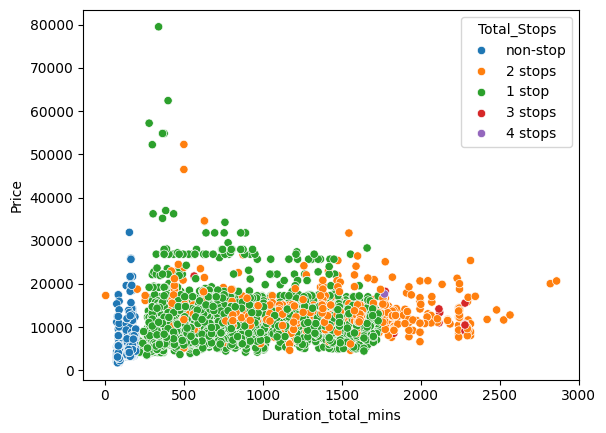

In [661]:
sns.scatterplot(x="Duration_total_mins" , y="Price" , hue="Total_Stops", data=data)

In [662]:
'''
Non stops flights take less duration while their fare is also low, then as the stop increases,
duration also increases and price also increases(in most of the cases)

'''

'\nNon stops flights take less duration while their fare is also low, then as the stop increases,\nduration also increases and price also increases(in most of the cases)\n\n'

## 8.. on which route Jet Airways is extremely used?

In [663]:
data['Airline']=='Jet Airways'

0        False
1        False
2         True
3        False
4        False
         ...  
10678    False
10679    False
10680     True
10681    False
10682    False
Name: Airline, Length: 10682, dtype: bool

In [664]:
data[data['Airline']=='Jet Airways'].groupby('Route').size().sort_values(ascending=False)

Route
CCU → BOM → BLR          930
DEL → BOM → COK          875
BLR → BOM → DEL          385
BLR → DEL                382
CCU → DEL → BLR          300
DEL → JAI → BOM → COK    207
BOM → HYD                207
DEL → AMD → BOM → COK    141
DEL → IDR → BOM → COK     86
DEL → NAG → BOM → COK     61
DEL → ATQ → BOM → COK     38
DEL → COK                 34
DEL → BHO → BOM → COK     29
DEL → BDQ → BOM → COK     28
DEL → LKO → BOM → COK     25
DEL → JDH → BOM → COK     23
CCU → GAU → BLR           22
DEL → MAA → BOM → COK     16
DEL → IXC → BOM → COK     13
BLR → MAA → DEL           10
BLR → BDQ → DEL            8
DEL → UDR → BOM → COK      7
BOM → DEL → HYD            5
CCU → BOM → PNQ → BLR      4
BLR → BOM → JDH → DEL      3
DEL → DED → BOM → COK      2
BOM → BDQ → DEL → HYD      2
BOM → IDR → DEL → HYD      1
BOM → VNS → DEL → HYD      1
BOM → DED → DEL → HYD      1
BOM → JDH → DEL → HYD      1
BOM → UDR → DEL → HYD      1
DEL → CCU → BOM → COK      1
dtype: int64

### b.. Performing Airline vs Price Analysis..
        ie find price distribution & 5-point summary of each Airline..

In [665]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_hour', 'Duration_minute',
       'Duration_total_mins'],
      dtype='str')

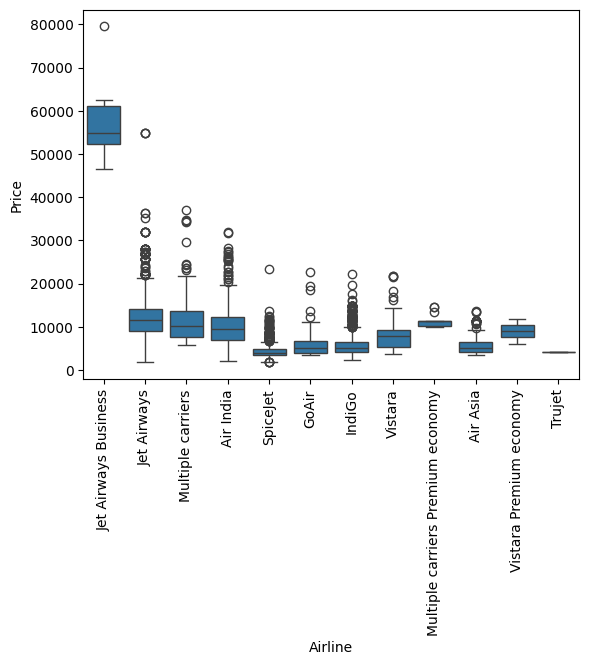

In [666]:
sns.boxplot(y='Price' , x='Airline' , data=data.sort_values('Price' , ascending=False))
plt.xticks(rotation="vertical")
plt.show()

In [667]:
'''

Conclusion--> From graph we can see that Jet Airways Business have the highest Price.,
              Apart from the first Airline almost all are having similar median

'''

'\n\nConclusion--> From graph we can see that Jet Airways Business have the highest Price.,\n              Apart from the first Airline almost all are having similar median\n\n'

## 9.. Applying one-hot Encoding on data..

In [668]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Journey_year,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,2019,22,20,1,10,2,50,2,50,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,2019,5,50,13,15,7,25,7,25,445


In [669]:
'''

Categorical data refers to a data type that can be stored into groups/categories/labels
Examples of categorical variables are  age group, educational level,blood type etc..


Numerical data refers to the data that is in the form of numbers,
Examples of numerical data are height, weight, age etc..

Numerical data has two categories: discrete data and continuous data


Discrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on.
                In case of infinity, these numbers will keep going on...
                age of a fly : 8 , 9 day etc..

Continuous data : which is continuous in nature
                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !

For example, salary levels and performance classifications are discrete variables,
whereas height and weight are continuous variables.

'''

'\n\nCategorical data refers to a data type that can be stored into groups/categories/labels\nExamples of categorical variables are  age group, educational level,blood type etc..\n\n\nNumerical data refers to the data that is in the form of numbers,\nExamples of numerical data are height, weight, age etc..\n\nNumerical data has two categories: discrete data and continuous data\n\n\nDiscrete data : It basically takes countable numbers like 1, 2, 3, 4, 5, and so on.\n                In case of infinity, these numbers will keep going on...\n                age of a fly : 8 , 9 day etc..\n\nContinuous data : which is continuous in nature\n                  amount of sugar , 11.2 kg  , temp of a city  , your bank balance !\n\nFor example, salary levels and performance classifications are discrete variables,\nwhereas height and weight are continuous variables.\n\n'

In [670]:
cat_col = [col for col in data.columns if data[col].dtype=="object"]

In [671]:
num_col = [col for col in data.columns if data[col].dtype!="object"]

#### Handling Categorical Data
    We are using 2 basic Encoding Techniques to convert Categorical data into some numerical format
    Nominal data --> data are not in any order --> OneHotEncoder is used in this case
    Ordinal data --> data are in order -->       LabelEncoder is used in this case
    
    But in real-world , it is not necessary that u have to always One-hot or label ,
    hence we will discuss more interesting approaches in upcoming sessions to do this !

In [672]:
cat_col

[]

In [673]:
### Applying One-hot from scratch :

In [674]:
data['Source'].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [675]:
data['Source'].apply(lambda x : 1 if x=='Banglore' else 0)

0        1
1        0
2        0
3        0
4        1
        ..
10678    0
10679    0
10680    1
10681    1
10682    0
Name: Source, Length: 10682, dtype: int64

In [676]:
for sub_category in data['Source'].unique():
    data['Source_'+sub_category] = data['Source'].apply(lambda x : 1 if x==sub_category else 0)

In [677]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,7,25,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,19,0,19,0,1140,0,0,1,0,0


## 10.. Lets Perform target guided encoding on Data
    ofcourse we can use One-hot , but if we have more sub-categories , it creates curse of dimensionality
    lets use Target Guided Mean Encoding in such case to get rid of curse of dimensionality..

In [678]:
'''

Now on 2 features , Airline & Destination , we can apply on-hot as there is no such order
but total_stops is my ordinal data , it makes no sense if we apply on-hot on top of this..
similarly if we have any feature which have more categories , it is not good to apply one-hot as it will create
curse of dimensionality issue , which leads to usage of more resources of your pc..

So we can think for appplying mean Encoding or better techniques like Target Guided Ordinal Encoding !


'''

'\n\nNow on 2 features , Airline & Destination , we can apply on-hot as there is no such order\nbut total_stops is my ordinal data , it makes no sense if we apply on-hot on top of this..\nsimilarly if we have any feature which have more categories , it is not good to apply one-hot as it will create\ncurse of dimensionality issue , which leads to usage of more resources of your pc..\n\nSo we can think for appplying mean Encoding or better techniques like Target Guided Ordinal Encoding !\n\n\n'

In [679]:
cat_col

[]

In [680]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,7,25,7,25,445,0,1,0,0,0


In [681]:
data['Airline'].nunique()

12

In [682]:
data.groupby(['Airline'])['Price'].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4338.284841
Air Asia                              5590.260188
IndiGo                                5673.682903
GoAir                                 5861.056701
Vistara                               7796.348643
Vistara Premium economy               8962.333333
Air India                             9612.427756
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11643.923357
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

In [683]:
airlines = data.groupby(['Airline'])['Price'].mean().sort_values().index

In [684]:
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='str', name='Airline')

In [685]:
dict_airlines = {key:index for index , key in enumerate(airlines , 0)}

In [686]:
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [687]:
data['Airline'] = data['Airline'].map(dict_airlines)

In [688]:
data['Airline']

0         3
1         7
2        10
3         3
4         3
         ..
10678     2
10679     7
10680    10
10681     5
10682     7
Name: Airline, Length: 10682, dtype: int64

In [689]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,7,25,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,19,0,19,0,1140,0,0,1,0,0


In [690]:
### now lets perform Target Guided Mean encoding on 'Destination' ..

In [691]:
data['Destination'].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [692]:
'''

till now , Delhi has only one Airport which is IGI & its second Airport is yet to build in Greater Noida (Jewar)
which is neighbouring part of Delhi so we will consider New Delhi & Delhi as same

but in future , these conditions may change..


'''

'\n\ntill now , Delhi has only one Airport which is IGI & its second Airport is yet to build in Greater Noida (Jewar)\nwhich is neighbouring part of Delhi so we will consider New Delhi & Delhi as same\n\nbut in future , these conditions may change..\n\n\n'

In [693]:
data['Destination'].replace('New Delhi' , 'Delhi' , inplace=True)

0           Delhi
1        Banglore
2          Cochin
3        Banglore
4           Delhi
           ...   
10678    Banglore
10679    Banglore
10680       Delhi
10681       Delhi
10682      Cochin
Name: Destination, Length: 10682, dtype: str

In [694]:
data['Destination'].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [695]:
dest = data.groupby(['Destination'])['Price'].mean().sort_values().index

In [696]:
dest

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin', 'New Delhi'], dtype='str', name='Destination')

In [697]:
dict_dest = {key:index for index , key in enumerate(dest , 0)}

In [698]:
dict_dest

{'Kolkata': 0,
 'Hyderabad': 1,
 'Delhi': 2,
 'Banglore': 3,
 'Cochin': 4,
 'New Delhi': 5}

In [699]:
data['Destination'] = data['Destination'].map(dict_dest)

In [700]:
data['Destination']

0        5
1        3
2        4
3        3
4        5
        ..
10678    3
10679    3
10680    2
10681    5
10682    4
Name: Destination, Length: 10682, dtype: int64

In [701]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,5,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,7,25,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,19,0,19,0,1140,0,0,1,0,0


## 11.. Perform Label(Manual) Encoding on Data

In [702]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,5,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,7,25,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,9,...,19,0,19,0,1140,0,0,1,0,0


In [703]:
data['Total_Stops']

0        non-stop
1         2 stops
2         2 stops
3          1 stop
4          1 stop
           ...   
10678    non-stop
10679    non-stop
10680    non-stop
10681    non-stop
10682     2 stops
Name: Total_Stops, Length: 10682, dtype: str

In [704]:
data['Total_Stops'].unique()

<StringArray>
['non-stop', '2 stops', '1 stop', '3 stops', '4 stops']
Length: 5, dtype: str

In [705]:
# As this is case of Ordinal Categorical type we perform Label encoding from scratch !
# Here Values are assigned with corresponding key

In [706]:
stop = {'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3, '4 stops':4}

In [707]:
data['Total_Stops'] = data['Total_Stops'].map(stop)

In [708]:
data['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

### b.. Remove Un-necessary features

In [709]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,5,BLR → DEL,2h 50m,0,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0


In [710]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_hour', 'Duration_minute',
       'Duration_total_mins', 'Source_Banglore', 'Source_Kolkata',
       'Source_Delhi', 'Source_Chennai', 'Source_Mumbai'],
      dtype='str')

In [711]:
data['Additional_Info'].value_counts()/len(data)*100

# Additional_Info contains almost 80% no_info,so we can drop this column

Additional_Info
No info                         78.112713
In-flight meal not included     18.554578
No check-in baggage included     2.995694
1 Long layover                   0.177869
Change airports                  0.065531
Business class                   0.037446
No Info                          0.028085
1 Short layover                  0.009362
Red-eye flight                   0.009362
2 Long layover                   0.009362
Name: count, dtype: float64

In [712]:
data.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,...,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,5,BLR → DEL,2h 50m,0,No info,3897,24,...,2,50,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,...,7,25,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2,No info,13882,9,...,19,0,19,0,1140,0,0,1,0,0
3,3,2019-05-12,Kolkata,3,CCU → NAG → BLR,5h 25m,1,No info,6218,12,...,5,25,5,25,325,0,1,0,0,0


In [713]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_day',
       'Journey_month', 'Journey_year', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_hour', 'Duration_minute',
       'Duration_total_mins', 'Source_Banglore', 'Source_Kolkata',
       'Source_Delhi', 'Source_Chennai', 'Source_Mumbai'],
      dtype='str')

In [714]:
data['Journey_year'].unique()

array([2019], dtype=int32)

In [715]:
'''

lets drop Date_of_Journey as well as we have already extracted "Journey_hour" , "jpuney_month" , Journey_day"..
Additional_Info contains almost 80% no_info , so we can drop this column ..
lets drop Duration_total_mins as we have already extracted "Duration_hours" & "Duration_mins"
Lets drop "Source" feature as well as we have already perform feature encoding on this Feature
lets drop Journey_year as well , as it has constant values throughtout dataframe which is 2019..

'''

'\n\nlets drop Date_of_Journey as well as we have already extracted "Journey_hour" , "jpuney_month" , Journey_day"..\nAdditional_Info contains almost 80% no_info , so we can drop this column ..\nlets drop Duration_total_mins as we have already extracted "Duration_hours" & "Duration_mins"\nLets drop "Source" feature as well as we have already perform feature encoding on this Feature\nlets drop Journey_year as well , as it has constant values throughtout dataframe which is 2019..\n\n'

In [716]:
data.drop(['Date_of_Journey' , 'Additional_Info' , 'Duration_total_mins' , 'Source' , 'Journey_year'] , axis=1 , inplace=True)

In [717]:
data.columns

Index(['Airline', 'Destination', 'Route', 'Duration', 'Total_Stops', 'Price',
       'Journey_day', 'Journey_month', 'Dep_Time_hour', 'Dep_Time_minute',
       'Arrival_Time_hour', 'Arrival_Time_minute', 'Duration_hours',
       'Duration_mins', 'Duration_hour', 'Duration_minute', 'Source_Banglore',
       'Source_Kolkata', 'Source_Delhi', 'Source_Chennai', 'Source_Mumbai'],
      dtype='str')

In [718]:
data.head(4)

,Airline,Destination,Route,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,...,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,5,BLR → DEL,2h 50m,0,3897,24,3,22,20,...,10,2,50,2,50,1,0,0,0,0
1,7,3,CCU → IXR → BBI → BLR,7h 25m,2,7662,1,5,5,50,...,15,7,25,7,25,0,1,0,0,0
2,10,4,DEL → LKO → BOM → COK,19h 0m,2,13882,9,6,9,25,...,25,19,0,19,0,0,0,1,0,0
3,3,3,CCU → NAG → BLR,5h 25m,1,6218,12,5,18,5,...,30,5,25,5,25,0,1,0,0,0


In [719]:
data.drop(columns=['Route'] ,  inplace=True)

## we can drop Route as well bcz Route is directly related to Total stops & considering 2 same features doesnt make sense while building ML model..

In [720]:
data.head(3)

,Airline,Destination,Duration,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,5,2h 50m,0,3897,24,3,22,20,1,10,2,50,2,50,1,0,0,0,0
1,7,3,7h 25m,2,7662,1,5,5,50,13,15,7,25,7,25,0,1,0,0,0
2,10,4,19h 0m,2,13882,9,6,9,25,4,25,19,0,19,0,0,0,1,0,0


In [721]:
data.drop(['Duration'] , axis=1 , inplace=True)

## we can drop "Duration" feature as we have extracted "Duration hour" & "Duration Minute"..

In [722]:
data.head(3)

,Airline,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_Time_hour,Dep_Time_minute,Arrival_Time_hour,Arrival_Time_minute,Duration_hours,Duration_mins,Duration_hour,Duration_minute,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,5,0,3897,24,3,22,20,1,10,2,50,2,50,1,0,0,0,0
1,7,3,2,7662,1,5,5,50,13,15,7,25,7,25,0,1,0,0,0
2,10,4,2,13882,9,6,9,25,4,25,19,0,19,0,0,0,1,0,0


## 12.. Lets Perform outlier detection !

#### Here the list of data visualization plots to spot the outliers.
    1. Box and whisker plot (box plot).
    2. Scatter plot.
    3. Histogram.
    4. Distribution Plot.


In [723]:
def plot(df, col):
    fig , (ax1 , ax2 , ax3) = plt.subplots(3,1)

    sns.distplot(df[col] , ax=ax1)
    sns.boxplot(df[col] , ax=ax2)
    sns.distplot(df[col] , ax=ax3 , kde=False)

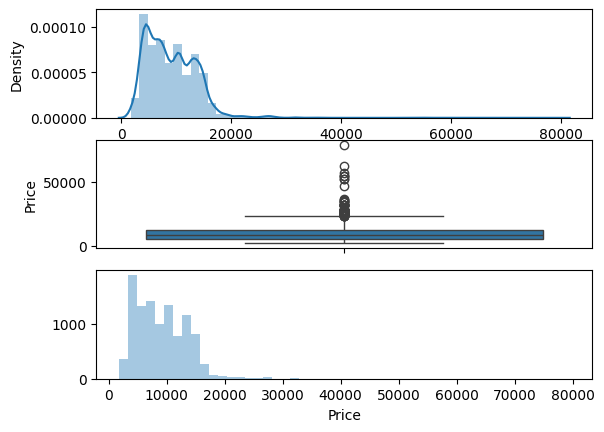

In [724]:
plot(data , 'Price')

        If Features Are Skewed We Use the below Technique which is IQR
        Data which are greater than IQR +1.5 IQR and data which are below than IQR - 1.5 IQR are my outliers
        where ,  IQR = 75th%ile data - 25th%ile data
         
         & IQR +- 1.5 IQR  will be changed depending upon the domain ie it could be sometimes IQR +- 3IQR
          


In [725]:
q1 = data['Price'].quantile(0.25)
q3 = data['Price'].quantile(0.75)

iqr = q3- q1

maximum = q3 + 1.5*iqr
minimum = q1 - 1.5*iqr

In [726]:
print(maximum)

23017.0


In [727]:
print(minimum)

-5367.0


In [728]:
print([price for price in data['Price'] if price> maximum or price<minimum])

[27430, 36983, 26890, 26890, 25139, 27210, 52229, 26743, 26890, 25735, 27992, 26890, 26890, 23583, 26890, 23533, 24115, 25735, 54826, 31783, 27992, 26890, 26890, 25430, 36235, 27210, 26890, 25735, 54826, 26890, 35185, 79512, 28097, 27992, 26890, 25735, 26092, 31825, 25913, 25735, 27992, 31825, 23267, 62427, 54826, 31825, 25430, 26890, 36235, 23843, 26890, 25735, 28322, 25735, 25735, 31825, 26890, 27992, 34273, 46490, 29528, 26890, 26890, 26890, 34503, 26890, 27992, 26890, 26890, 23170, 24528, 26890, 27992, 25735, 34608, 25703, 26890, 23528, 31825, 27282, 25735, 27992, 52285, 24017, 31945, 26890, 24318, 23677, 27992, 24210, 57209, 26890, 31825, 26480]


In [729]:
len([price for price in data['Price'] if price> maximum or price<minimum])

94

### b.. How to deal with Outlier

In [730]:
### wherever I have price >35K just replace replace it with median of Price

data['Price'] = np.where(data['Price']>=35000 , data['Price'].median() , data['Price'])

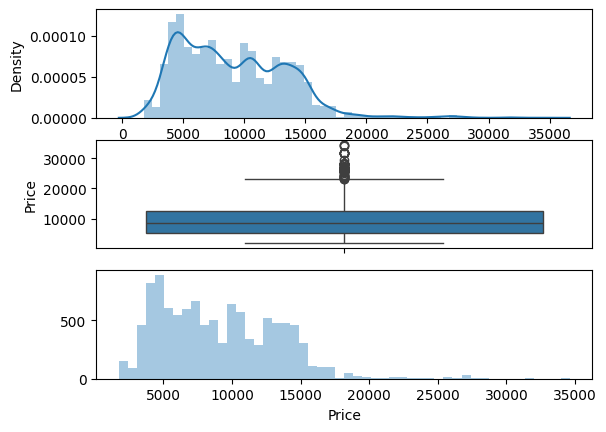

In [731]:
plot(data , 'Price')

## 13.. Lets Perform feature selection

In [732]:
'''
    : Feature Selection
    Finding out the best feature which will contribute and have good relation with target variable.


    Q-> Why to apply Feature Selection?
    To select important features ie to get rid of curse of dimensionality ie..or to get rid of duplicate features

'''

'\n    : Feature Selection\n    Finding out the best feature which will contribute and have good relation with target variable.\n\n\n    Q-> Why to apply Feature Selection?\n    To select important features ie to get rid of curse of dimensionality ie..or to get rid of duplicate features\n\n'

In [733]:
X = data.drop(['Price'] , axis=1)

In [734]:
y = data['Price']

In [735]:
from sklearn.feature_selection import mutual_info_regression

In [736]:
imp = mutual_info_regression(X , y)

In [737]:
'''
Estimate mutual information for a continuous target variable.

Mutual information between two random variables is a non-negative
value, which measures the dependency between the variables.
If It is equal to zero it means two random variables are independent, and higher
values mean higher dependency.

'''


'\nEstimate mutual information for a continuous target variable.\n\nMutual information between two random variables is a non-negative\nvalue, which measures the dependency between the variables.\nIf It is equal to zero it means two random variables are independent, and higher\nvalues mean higher dependency.\n\n'

In [738]:
imp

array([1.31922446, 1.17315107, 0.78940172, 0.37024923, 0.620239  ,
       0.9226427 , 0.75927057, 1.13983928, 0.89990081, 1.12786519,
       0.67139975, 0.95496967, 0.67967906, 0.39167065, 0.44919561,
       0.5137493 , 0.13447171, 0.20004177])

In [739]:
imp_df = pd.DataFrame(imp , index=X.columns)

In [740]:
imp_df.columns = ['importance']

In [741]:
imp_df

,importance
Airline,1.319224
Destination,1.173151
Total_Stops,0.789402
Journey_day,0.370249
Journey_month,0.620239
Dep_Time_hour,0.922643
Dep_Time_minute,0.759271
Arrival_Time_hour,1.139839
Arrival_Time_minute,0.899901
Duration_hours,1.127865


In [742]:
imp_df.sort_values(by='importance' , ascending=False)

,importance
Airline,1.319224
Destination,1.173151
Arrival_Time_hour,1.139839
Duration_hours,1.127865
Duration_hour,0.954970
Dep_Time_hour,0.922643
Arrival_Time_minute,0.899901
Total_Stops,0.789402
Dep_Time_minute,0.759271
Duration_minute,0.679679


## 14.. Lets Build ML model

#### split dataset into train & test

In [743]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb

In [744]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### what we often do in modelling:

    a..Initially ,lets build basic random model.
    b..then later-on , we will try to improve this model using some parameters..
    c..Then we will try to improve it..
    d..Then we will hyper-tune my model to get optimal value of parameters in order to achieve optimal value of params..

In [745]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MSE",mean_squared_error(y_test,y_pred))

 # 🌲 1. Random Forest (BEST BASELINE)

In [746]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Results:")
evaluate_model(rf, X_test, y_test)

Random Forest Results:
R2 Score: 0.8148160388981329
MAE: 1250.8343477636436
RMSE: 1930.9928424013897
MSE 3728733.3574053985


#🌳 2. Decision Tree (Simple Model)


In [747]:
dt = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

print("Decision Tree Results:")
evaluate_model(dt, X_test, y_test)

Decision Tree Results:
R2 Score: 0.7906111660781385
MAE: 1253.2054677463973
RMSE: 2053.3157499801764
MSE 4216105.569116655


 # 3. Gradient Boosting (Strong Model)

In [748]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)

gb.fit(X_train, y_train)

print("Gradient Boosting Results:")
evaluate_model(gb, X_test, y_test)

Gradient Boosting Results:
R2 Score: 0.8357281871802398
MAE: 1230.1071473764098
RMSE: 1818.6976438579857
MSE 3307661.1197745884


# 4. XGBoost (BEST PERFORMANCE 🔥)

In [749]:
xgbr = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgbr.fit(X_train, y_train)

print("XGBoost Results:")
evaluate_model(xgbr, X_test, y_test)

XGBoost Results:
R2 Score: 0.8415464545617706
MAE: 1154.9365098995197
RMSE: 1786.1994849356463
MSE 3190508.5999843683


### b.. Lets Save model

#### lets try to dump ml model using pickle or joblib..
    advantage of dumping--
    imagine in future we have new data & lets say we have to predict price on this huge data

    then to do prediction on this new data , we can use this pre-trained model what we have dumped..


In [750]:
!pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for pickle


In [751]:
import pickle

In [752]:
!pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# SAVE ALL MODELS

In [753]:
import joblib
import os

# Create the 'model' directory if it doesn't exist
os.makedirs('model', exist_ok=True)

# Save all 4 models
joblib.dump(dt,  'model/decision_tree_model.pkl')
joblib.dump(rf,  'model/random_forest_model.pkl')
joblib.dump(xgbr, 'model/xgboost_model.pkl')
joblib.dump(gb,  'model/gradient_boost_model.pkl')

# Save feature columns (needed for deployment)
joblib.dump(list(X.columns), 'model/feature_columns.pkl')
joblib.dump(list(X.columns), 'model/feature_cols.pkl')  # alias for Flask app

# Save best model separately for Flask deployment
best_model_for_deploy = rf  # Random Forest — best balance
joblib.dump(best_model_for_deploy, 'model/best_model.pkl')

print('✅ All models saved:')
print('   model/decision_tree_model.pkl')
print('   model/random_forest_model.pkl')
print('   model/xgboost_model.pkl')
print('   model/gradient_boost_model.pkl')
print('   model/best_model.pkl  (Random Forest — for deployment)')
print('   model/feature_columns.pkl')

✅ All models saved:
   model/decision_tree_model.pkl
   model/random_forest_model.pkl
   model/xgboost_model.pkl
   model/gradient_boost_model.pkl
   model/best_model.pkl  (Random Forest — for deployment)
   model/feature_columns.pkl


# Predict on Official Test Set

In [754]:
# Generate predictions on the held-out test set with all 4 models
test_predictions = pd.DataFrame({
    'DT_Prediction_Rs':  dt.predict(X_test),
    'RF_Prediction_Rs':  rf.predict(X_test),
    'XGB_Prediction_Rs': xgbr.predict(X_test),
    'GB_Prediction_Rs':  gb.predict(X_test),
})
test_predictions['Ensemble_Avg_Rs'] = test_predictions.mean(axis=1).round()
test_predictions = test_predictions.round(2)

print('Test Set Predictions (first 5 rows):')
print(test_predictions.head().to_string())

test_predictions.to_csv('model/test_predictions.csv', index=False)
print('\n✅ Predictions saved → model/test_predictions.csv')

Test Set Predictions (first 5 rows):
   DT_Prediction_Rs  RF_Prediction_Rs  XGB_Prediction_Rs  GB_Prediction_Rs  Ensemble_Avg_Rs
0          16311.50          16443.91       17210.740234          17647.48          16903.0
1           4617.83           5573.66        5766.089844           6672.88           5658.0
2           8601.00           8595.67        8329.959961           8300.00           8457.0
3           3611.57           3718.63        3955.060059           3980.72           3816.0
4          15018.67          14089.29       14514.360352          13693.75          14329.0

✅ Predictions saved → model/test_predictions.csv


## 🌐 Flask Deployment — app.py

Run the following steps in your terminal to launch the web application:

In [ ]:
# ── Deployment Instructions ──────────────────────────────────────────────
# Step 1: Make sure all models are saved (run cell above first)
# Step 2: Open a terminal in this project folder
# Step 3: Run:  python app.py
# Step 4: Open browser:  http://127.0.0.1:5000

print("""
╔══════════════════════════════════════════════════════════╗
║  ✈️  AIRLINE FARE PREDICTION — FLASK DEPLOYMENT          ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Install dependencies:                                ║
║     pip install flask pandas numpy scikit-learn joblib   ║
║                                                          ║
║  2. Run from terminal:                                   ║
║     python app.py                                        ║
║                                                          ║
║  3. Open browser at:                                     ║
║     http://127.0.0.1:5000                                ║
║                                                          ║
║  4. REST API endpoint:                                   ║
║     POST http://127.0.0.1:5000/api/predict               ║
║                                                          ║
║  Project structure:                                      ║
║    flight_project/                                       ║
║    ├── app.py                ← Flask app                 ║
║    ├── Adhithya_project.ipynb ← this notebook            ║
║    ├── Data_Train.xlsx       ← dataset                   ║
║    ├── requirements.txt      ← dependencies              ║
║    ├── model/                ← saved .pkl files          ║
║    │   ├── random_forest_model.pkl                       ║
║    │   ├── decision_tree_model.pkl                       ║
║    │   ├── xgboost_model.pkl                             ║
║    │   ├── gradient_boost_model.pkl                      ║
║    │   ├── best_model.pkl                                ║
║    │   └── feature_columns.pkl                           ║
║    └── templates/                                        ║
║        └── index.html        ← web interface             ║
╚══════════════════════════════════════════════════════════╝
""")

### app.py — Flask Web Application Source Code

The complete `app.py` file is in the project folder. Key components:
- Loads all 4 trained models from `model/` folder using `joblib`
- Encodes user input using the **exact same pipeline** as training
- Returns predictions from all 4 models + ensemble average
- Provides a REST API at `/api/predict` accepting JSON

In [ ]:
# ── Verify Flask app can load models ─────────────────────────────────────
import joblib, os

MODEL_DIR = "model"
required_files = [
    "random_forest_model.pkl",
    "decision_tree_model.pkl",
    "xgboost_model.pkl",
    "gradient_boost_model.pkl",
    "best_model.pkl",
    "feature_columns.pkl",
]

print("Checking model files...")
all_ok = True
for fname in required_files:
    path = os.path.join(MODEL_DIR, fname)
    exists = os.path.exists(path)
    size = os.path.getsize(path)//1024 if exists else 0
    status = f"✅  {path}  ({size} KB)" if exists else f"❌  {path}  MISSING"
    print(status)
    if not exists: all_ok = False

if all_ok:
    print("\n✅  All model files present — run:  python app.py")
else:
    print("\n❌  Some files missing — run the model saving cell first!")

### Feature Encoding Reference

The Flask app uses these encoding maps (must match training exactly):

In [ ]:
# Encoding maps used in Flask app  (same as training pipeline)

AIRLINE_ENC = {
    'Trujet': 0, 'SpiceJet': 1, 'Air Asia': 2, 'IndiGo': 3,
    'GoAir': 4, 'Vistara': 5, 'Vistara Premium economy': 6,
    'Air India': 7, 'Multiple carriers': 8,
    'Multiple carriers Premium economy': 9,
    'Jet Airways': 10, 'Jet Airways Business': 11,
}

DEST_ENC = {
    'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2,
    'Banglore': 3, 'Cochin': 4, 'New Delhi': 2,  # New Delhi → Delhi
}

STOPS_ENC = {
    'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4
}

print("Airline encoding:", AIRLINE_ENC)
print("Destination encoding:", DEST_ENC)
print("Stops encoding:", STOPS_ENC)
print("Feature columns:", list(X.columns))

## 15.. How to automate ml pipeline & How to define your Evaluation metric..

### a.. how to make our own metric...

In [757]:
def mape(y_true , y_pred):
    y_true , y_pred = np.array(y_true) , np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [758]:
y_pred = xgbr.predict(X_test)
mape(y_test , y_pred)

np.float64(12.972779041902477)

### b.. How to automate ml pipeline !

In [759]:
'''

    Lets automate all the stuffs..
    let say ,I will just pass ml algo & i get several results like--

    Training score, predictions, r2_score, mse, mae, rmse, mape,distribution of error


'''

'\n\n    Lets automate all the stuffs..\n    let say ,I will just pass ml algo & i get several results like--\n\n    Training score, predictions, r2_score, mse, mae, rmse, mape,distribution of error\n\n\n'

In [760]:
from sklearn import metrics

In [761]:
def predict(ml_model):
    model = ml_model.fit(X_train , y_train)
    print('Training score : {}'.format(model.score(X_train , y_train)))
    y_predection = model.predict(X_test)
    print('predictions are : {}'.format(y_predection))
    print('\n')
    r2_score = metrics.r2_score(y_test , y_predection)
    print('r2 score : {}'.format(r2_score))
    print('MAE : {}'.format(metrics.mean_absolute_error(y_test , y_predection)))
    print('MSE : {}'.format(metrics.mean_squared_error(y_test , y_predection)))
    print('RMSE : {}'.format(np.sqrt(metrics.mean_squared_error(y_test , y_predection))))
    print('MAPE : {}'.format(mape(y_test , y_predection)))
    sns.distplot(y_test - y_predection)

Training score : 0.9510400620792869
predictions are : [16891.94        5357.25        8905.85       ...  6508.29
 12763.68333333 12742.05333333]


r2 score : 0.8125228323754532
MAE : 1185.8563853455337
MSE : 3774907.7431656835
RMSE : 1942.9121810225195
MAPE : 13.115906812112618


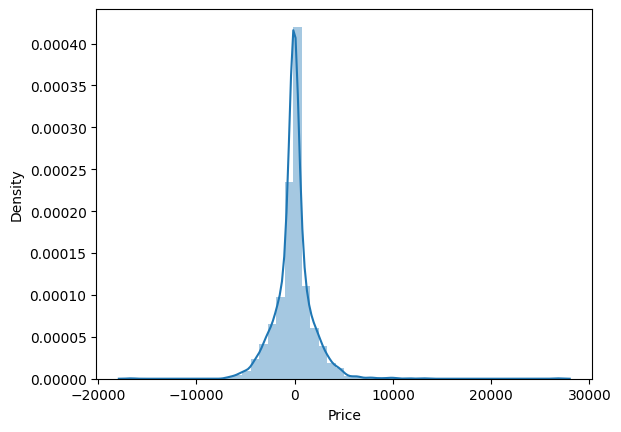

In [762]:
predict(RandomForestRegressor())

In [763]:
from sklearn.tree import DecisionTreeRegressor

Training score : 0.9651196669167478
predictions are : [16840.  4959.  9397. ...  6152. 13339. 14335.]


r2 score : 0.690899450181179
MAE : 1390.6338714709093
MSE : 6223830.206697993
RMSE : 2494.7605509743803
MAPE : 15.054544225162713


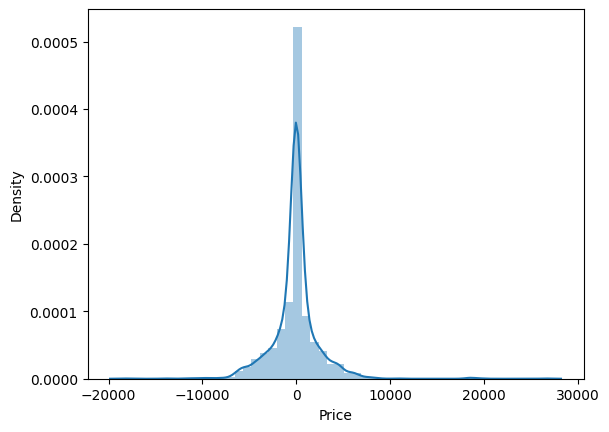

In [764]:
predict(DecisionTreeRegressor())

In [765]:
from xgboost import XGBRegressor

Training score : 0.9254288680846963
predictions are : [17354.172  5871.062  8260.547 ...  6174.475 12653.372 12884.93 ]


r2 score : 0.8381951968884458
MAE : 1153.23189200873
MSE : 3257987.155910241
RMSE : 1804.9895168422006
MAPE : 12.877219140261023


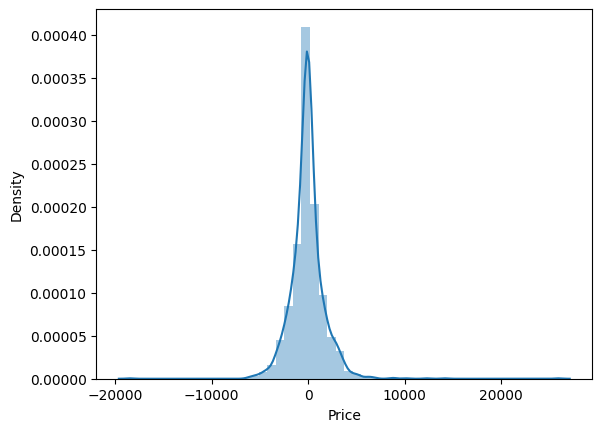

In [766]:
predict(XGBRegressor())

In [767]:
from sklearn.ensemble import GradientBoostingRegressor

Training score : 0.7758490282012389
predictions are : [15067.88996112  7024.87091955  8218.77185843 ...  5901.04667513
 11663.24345379 12324.15966002]


r2 score : 0.7579424359047566
MAE : 1539.7733555899654
MSE : 4873900.030455332
RMSE : 2207.691108478569
MAPE : 17.834191101054035


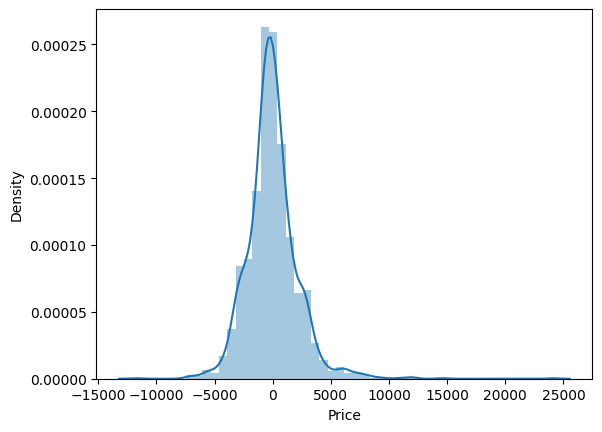

In [768]:
predict(GradientBoostingRegressor())

## 16.. how to hypertune ml model

In [769]:
## how to select which ML algo we should apply for
## ans is use Multiple Algos,then go for Hyper-parameter Optimization,then for Cross Validation then go for various metrics
## & based on domain expertise knowledge Then I can say ya this model perfoms best

### Hyperparameter Tuning or Hyperparameter Optimization
    1.Choose following method for hyperparameter tuning
        a.RandomizedSearchCV --> Fast way to Hypertune model
        b.GridSearchCV--> Slower way to hypertune my model
    2.Choose ML algo that u have to hypertune
    2.Assign hyperparameters in form of dictionary or create hyper-parameter space
    3.define searching &  apply searching on Training data or  Fit the CV model
    4.Check best parameters and best score

# GRID SEARCH -- SLOW

In [770]:
from sklearn.model_selection import GridSearchCV

# RANDOM FOREST

In [771]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


KeyboardInterrupt: 

# DECISION TREE

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['squared_error', 'friedman_mse']
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

dt_grid.fit(X_train, y_train)

print("Best DT Params:", dt_grid.best_params_)
best_dt = dt_grid.best_estimator_

# 3.Gradient Boosting

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

gb_grid.fit(X_train, y_train)

print("Best GB Params:", gb_grid.best_params_)
best_gb = gb_grid.best_estimator_

# 4.XGBOOST

In [ ]:
xgbr = xgb.XGBRegressor(random_state=42)

xgb_params = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

xgb_grid = GridSearchCV(
    estimator=xgbr,
    param_grid=xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

print("Best XGB Params:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_

# EVALUATE BEST MODEL

In [ ]:
models = {
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "Gradient Boosting": best_gb,
    "XGBoost": best_xgb
}

for name, model in models.items():
    print(f"\n{name}")
    evaluate_model(model, X_test, y_test)

RANDOMISED SEARCH CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 🌲 2. Random Forest – RandomizedSearchCV

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': randint(100, 500),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 6),
    'max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,              # 🔥 increase for better accuracy
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)
best_rf = rf_random.best_estimator_

# 🌳 2. Decision Tree – RandomizedSearchCV

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['squared_error', 'friedman_mse']
}

dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_params,
    n_iter=25,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

dt_random.fit(X_train, y_train)

print("Best DT Params:", dt_random.best_params_)
best_dt = dt_random.best_estimator_

#3. Gradient Boosting – RandomizedSearchCV

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 8),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 6),
    'subsample': uniform(0.7, 0.3)
}

gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

gb_random.fit(X_train, y_train)

print("Best GB Params:", gb_random.best_params_)
best_gb = gb_random.best_estimator_

# 5. XGBoost – RandomizedSearchCV (BEST 🔥)

In [ ]:
xgbr = xgb.XGBRegressor(random_state=42)

xgb_params = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 2)
}

xgb_random = RandomizedSearchCV(
    estimator=xgbr,
    param_distributions=xgb_params,
    n_iter=40,          # 🔥 increase to 50–100 for best performance
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

xgb_random.fit(X_train, y_train)

print("Best XGB Params:", xgb_random.best_params_)
best_xgb = xgb_random.best_estimator_

# EVALUATE MODEL

In [ ]:
models = {
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "Gradient Boosting": best_gb,
    "XGBoost": best_xgb
}

for name, model in models.items():
    print(f"\n{name}")
    evaluate_model(model, X_test, y_test)